In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define target
df = pd.read_csv(r"C:\Users\nandi\Documents\ML_CO2_ER\data\df_viscosity_clean.csv")
target = 'viscosity [Pa s]'
X = df.drop(columns=['solvent_ID', 'smiles', 'Binding_Energy_eV', 'solubility_CO2 [mol/L]', target])
y = df[target]

# Apply log transform
y_log = np.log1p(y)  # log1p handles small values safely

# Train-test split
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [2]:
y[:5]

0    0.011764
1    0.007448
2    0.002281
3    0.025603
4    0.001110
Name: viscosity [Pa s], dtype: float64

In [3]:
np.log1p(y[:5])

0    0.011696
1    0.007420
2    0.002278
3    0.025281
4    0.001109
Name: viscosity [Pa s], dtype: float64

In [4]:
df[target][:5]

0    0.011764
1    0.007448
2    0.002281
3    0.025603
4    0.001110
Name: viscosity [Pa s], dtype: float64

In [5]:
# Fit a radmom forest model with random search cross validation
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

from sklearn.model_selection import RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    cv=10,
    verbose=2,
    random_state=42,
    n_jobs=10
)

random_search.fit(X_train_scaled, y_train_log)
random_search.best_params_


Fitting 10 folds for each of 30 candidates, totalling 300 fits


{'n_estimators': 200,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': None,
 'max_depth': 30}

In [6]:
best_params = random_search.best_params_
model = RandomForestRegressor(
    **best_params,
    random_state=42
)

In [7]:
model.fit(X_train_scaled, y_train_log)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [8]:
y_pred_log = model.predict(X_test_scaled)
y_train_pred_log = model.predict(X_train_scaled)

# Optional: Clip logs to avoid overflow
# clip_max = 20
# y_pred_log = np.clip(y_pred_log, a_min=None, a_max=clip_max)

# Inverse log1p
y_pred = np.expm1(y_pred_log)
y_test = np.expm1(y_test_log)
y_train_pred = np.expm1(y_train_pred_log)
y_train_act = np.expm1(y_train_log)


In [9]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse1 = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
r2 = r2_score(y_test, y_pred)

print(f"Fixed RMSE: {rmse:.4f}")
print(f"Fixed RMSE1: {rmse1:.4f}")
print(f"Fixed R²: {r2:.4f}")


Fixed RMSE: 0.0027
Fixed RMSE1: 0.0027
Fixed R²: 0.8964


In [10]:
feature_names = X.columns.tolist()  # This should match the model's input

c:\Users\nandi\Documents\ML_CO2_ER\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 98%|===================| 492/501 [00:34<00:00]        

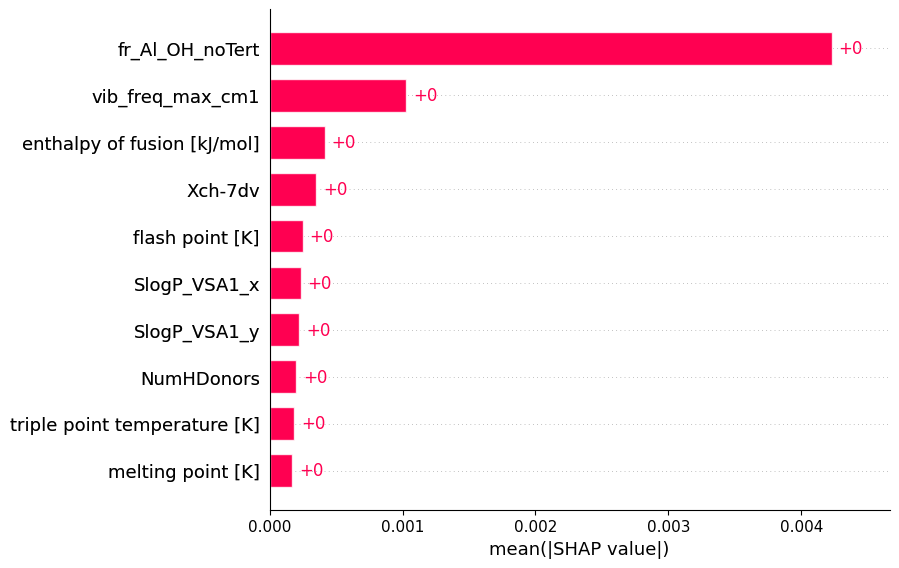

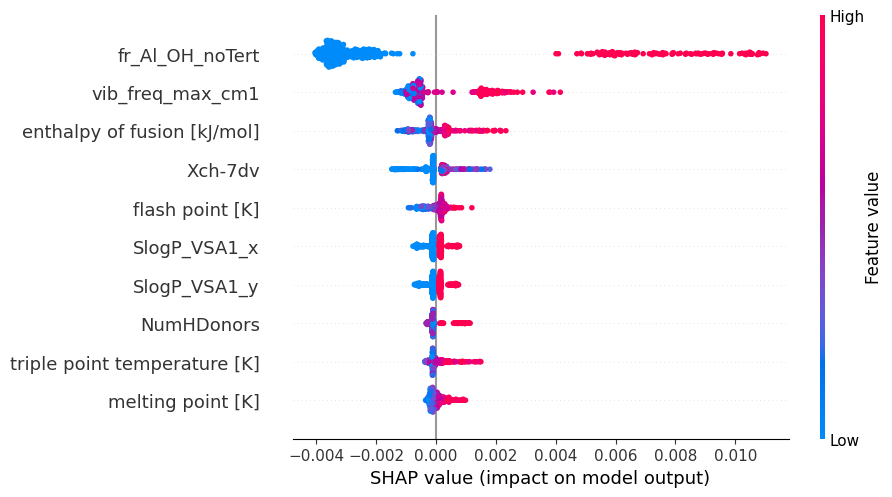

In [11]:
import shap
import numpy as np

# SHAP explainer on log-transformed model
explainer = shap.Explainer(model, X_test_scaled, feature_names=X.columns)
shap_values = explainer(X_test_scaled)

# Compute mean SHAP values (log-space)
mean_shap = np.abs(shap_values.values).mean(axis=0)
top_10_indices = np.argsort(mean_shap)[-10:][::-1]

# Slice SHAP explanation for top 10 features
shap_values_top10 = shap.Explanation(
    values=shap_values.values[:, top_10_indices],
    base_values=shap_values.base_values,
    data=shap_values.data[:, top_10_indices],
    feature_names=np.array(shap_values.feature_names)[top_10_indices].tolist()
)

# Plot
shap.plots.bar(shap_values_top10)
shap.plots.beeswarm(shap_values_top10)

 98%|===================| 492/501 [00:36<00:00]        

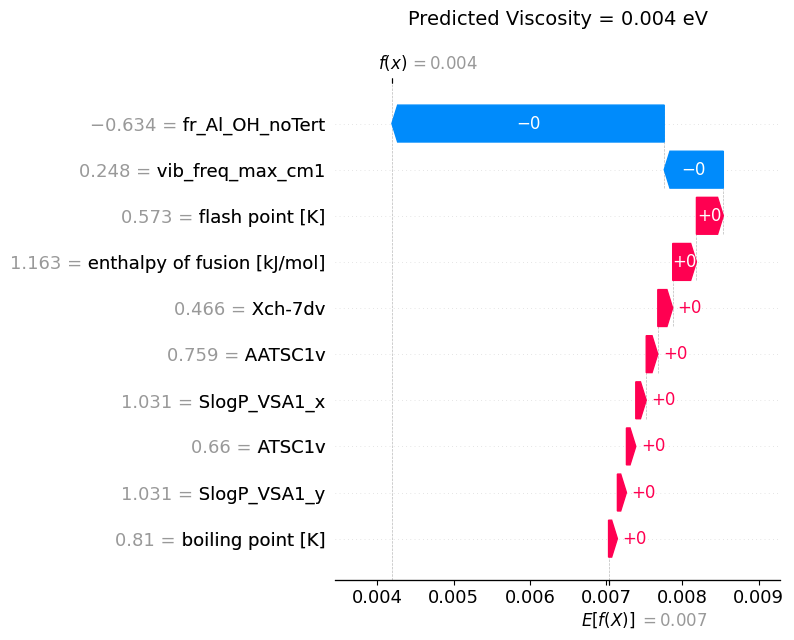

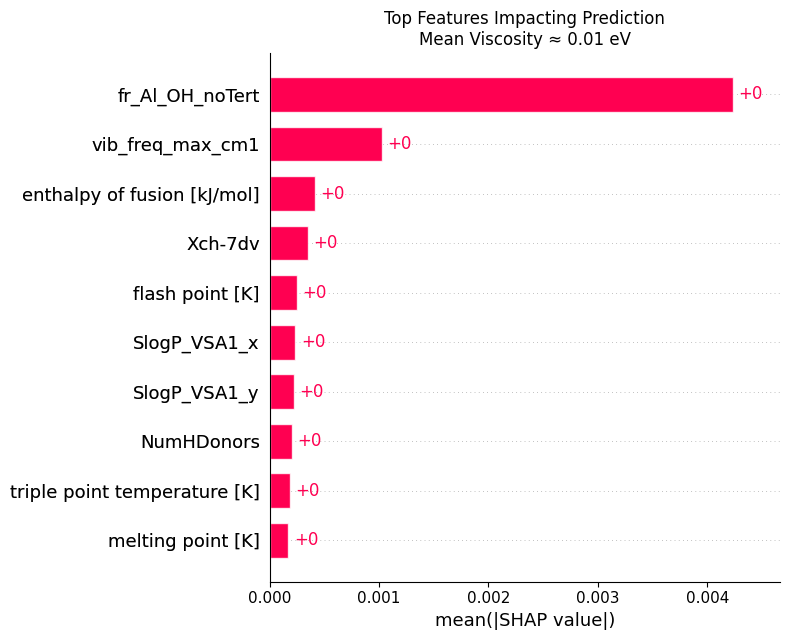

In [13]:
import matplotlib.pyplot as plt

# Create SHAP explainer
explainer = shap.Explainer(model, X_test_scaled, feature_names=X.columns)
shap_values = explainer(X_test_scaled)

# Choose one sample index
i = 1

sample_shap = shap_values[i]

# Compute predicted log value and actual value
top10_idx = np.argsort(np.abs(sample_shap.values))[-10:][::-1]

# Note: This is only for a sample of data, not the entire data
# Create a new Explanation object with only top 10 features
sample_shap_top10 = shap.Explanation(
    values=sample_shap.values[top10_idx],
    base_values=sample_shap.base_values,
    data=sample_shap.data[top10_idx],
    feature_names=np.array(sample_shap.feature_names)[top10_idx].tolist()
)

log_pred = shap_values.base_values[i] + shap_values.values[i].sum()
actual_pred = np.expm1(log_pred)

# Plotly waterfall plot
fig = shap.plots.waterfall(sample_shap_top10, show=False)
fig.set_title(f"Predicted Viscosity = {actual_pred:.3f} eV", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

mean_shap = np.abs(shap_values.values).mean(axis=0)

top10_global_idx = np.argsort(mean_shap)[-10:][::-1]

shap_values_top10 = shap.Explanation(
    values=shap_values.values[:, top10_global_idx],
    base_values=shap_values.base_values,
    data=shap_values.data[:, top10_global_idx],
    feature_names=np.array(shap_values.feature_names)[top10_global_idx].tolist()
)

fig = shap.plots.bar(shap_values_top10, show=False)
fig.set_title(f"Top Features Impacting Prediction\nMean Viscosity ≈ {np.expm1(shap_values.base_values.mean()):.2f} eV", fontsize=12)

plt.tight_layout()
plt.show()

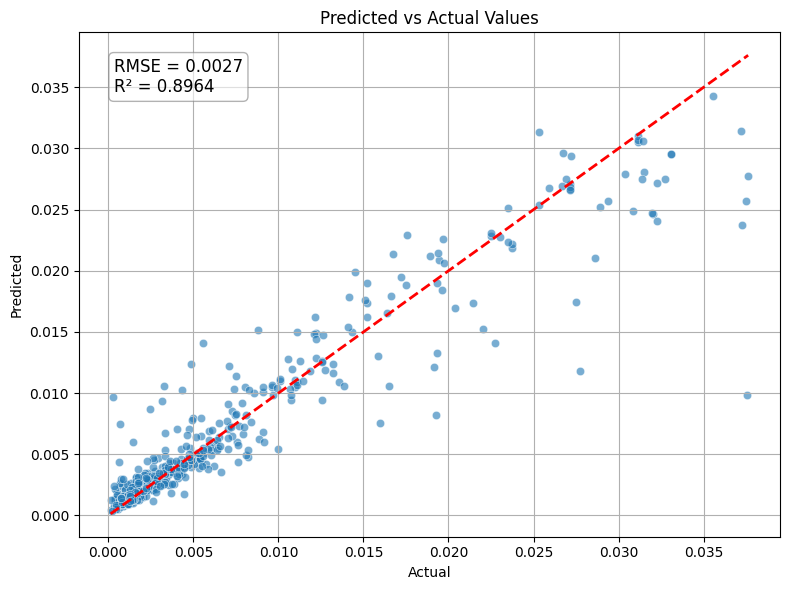

In [14]:
residuals = y_test - y_pred

import matplotlib.pyplot as plt
import seaborn as sns 

# --- A. Predicted vs Actual Plot ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)

# Reference line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2)

# Annotate RMSE and R² inside the plot
plt.text(
    0.05, 0.95,
    f"RMSE = {rmse:.4f}\nR² = {r2:.4f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.6)
)

plt.title("Predicted vs Actual Values")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

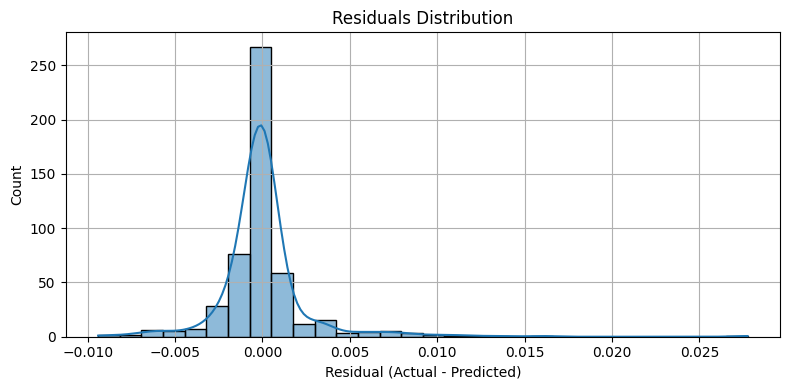

In [15]:
# --- B. Histogram of Residuals ---
plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True, bins=30)
plt.title("Residuals Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.6)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
ax.set_title("Predicted vs Actual Values")
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
ax.legend([f'RMSE = {rmse:.4f}\nR² = {r2:.4f}'], loc='upper left')

# Inset Plot: Residuals Distribution
inset_ax = inset_axes(ax, width="30%", height="30%", loc='lower right', borderpad=2)
sns.histplot(residuals, bins=30, kde=True, ax=inset_ax)
inset_ax.set_title("Residuals", fontsize=8)
inset_ax.set_xlabel("")
inset_ax.set_ylabel("")
inset_ax.tick_params(labelsize=6)

C:\Users\nandi\AppData\Local\Temp\ipykernel_25660\1650586806.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


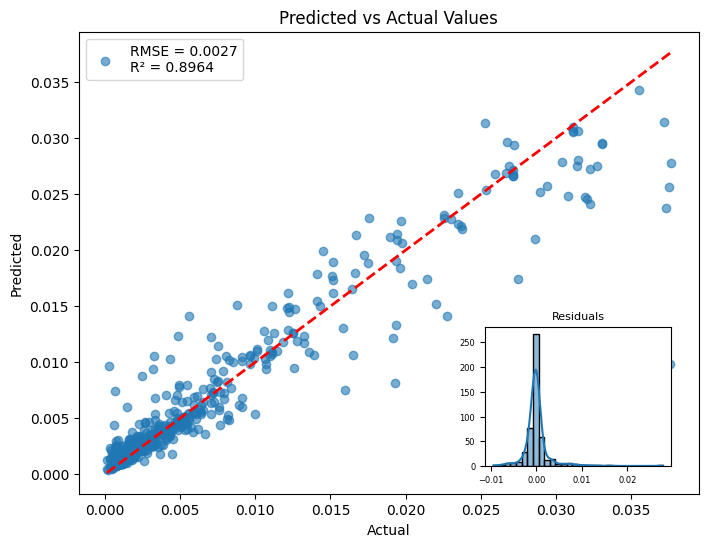

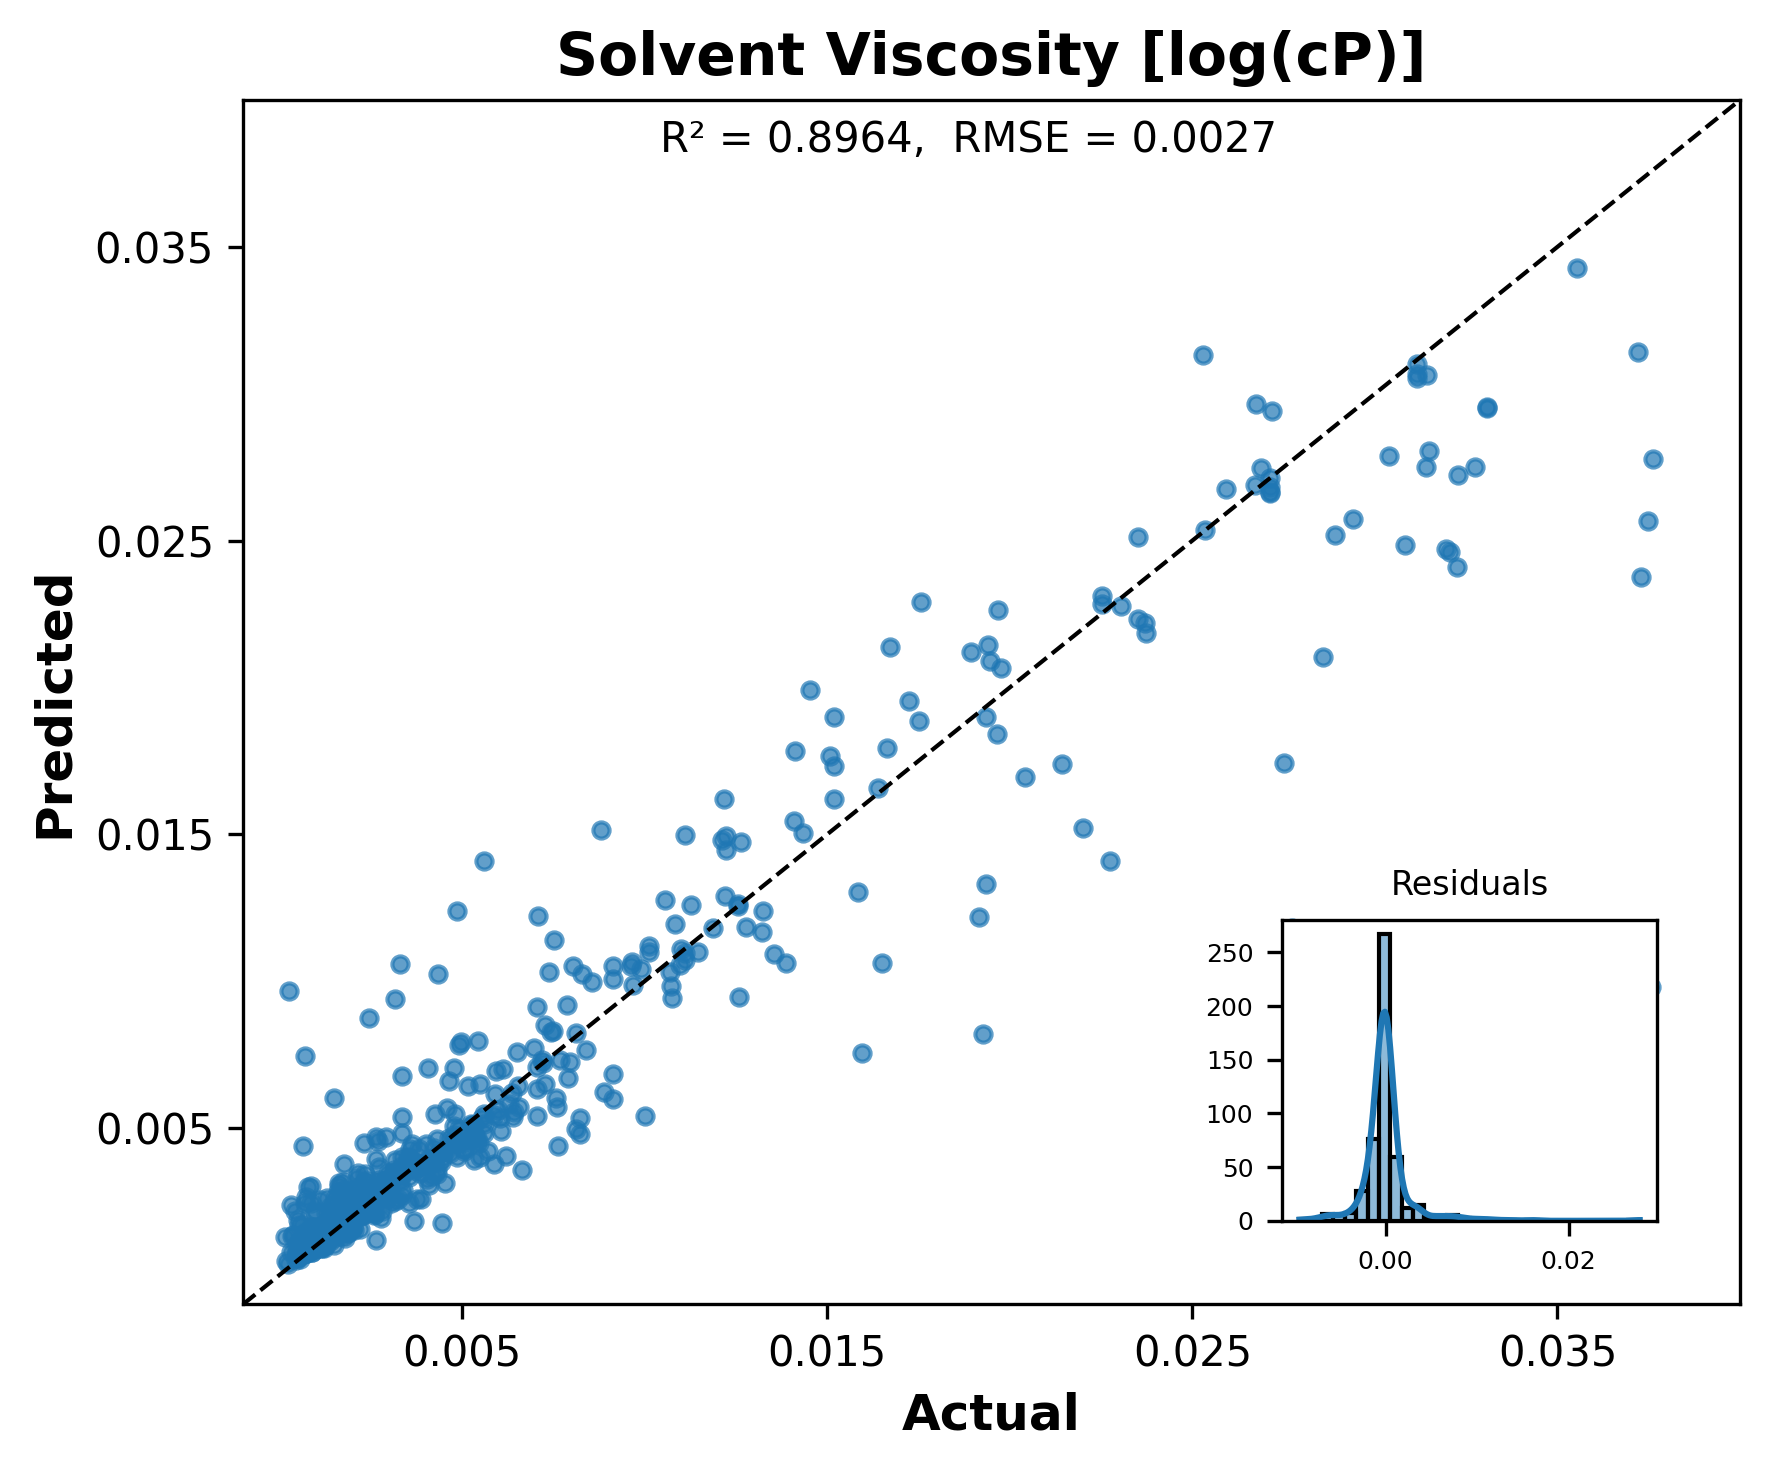

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

# ➤ Scatter plot and diagonal line
ax.scatter(y_test, y_pred, alpha=0.7, s=15)
ax.plot([-0.001, 0.040], [-0.001, 0.040], 'k--', linewidth=1)

# ➤ Main plot labels
ax.set_title("Solvent Viscosity [log(cP)]", fontsize=14, fontweight='bold')
ax.set_xlabel("Actual", fontsize=12, fontweight='bold')
ax.set_ylabel("Predicted", fontsize=12, fontweight='bold')
ax.set_xlim(-0.001, 0.040)
ax.set_ylim(-0.001, 0.040)
ax.set_xticks([0.005, 0.015,0.025,0.035])
ax.set_yticks([0.005, 0.015,0.025,0.035])
ax.tick_params(axis='both', labelsize=10)

# ➤ R² and RMSE just inside top center of axes
x_center = (y_test.min() + y_test.max()) / 2
y_top = y_pred.max() + (y_pred.max() - y_pred.min()) * 0.15
ax.text(x_center, y_top, f"R² = {r2:.4f},  RMSE = {rmse:.4f}",
        fontsize=10, ha='center', va='top')

# ➤ Inset plot for residuals
inset_ax = inset_axes(ax, width="25%", height="25%", loc='lower right', borderpad=2)


sns.histplot(residuals, bins=30, kde=True, ax=inset_ax)
inset_ax.set_title("Residuals", fontsize=8)
inset_ax.set_xlabel("")
inset_ax.set_ylabel("")
inset_ax.tick_params(labelsize=6)

# ➤ Adjust layout and save
plt.tight_layout()
plt.savefig("solvent_viscosity_fixed.png", dpi=300, bbox_inches='tight')
plt.show()


C:\Users\nandi\AppData\Local\Temp\ipykernel_25660\2442506040.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


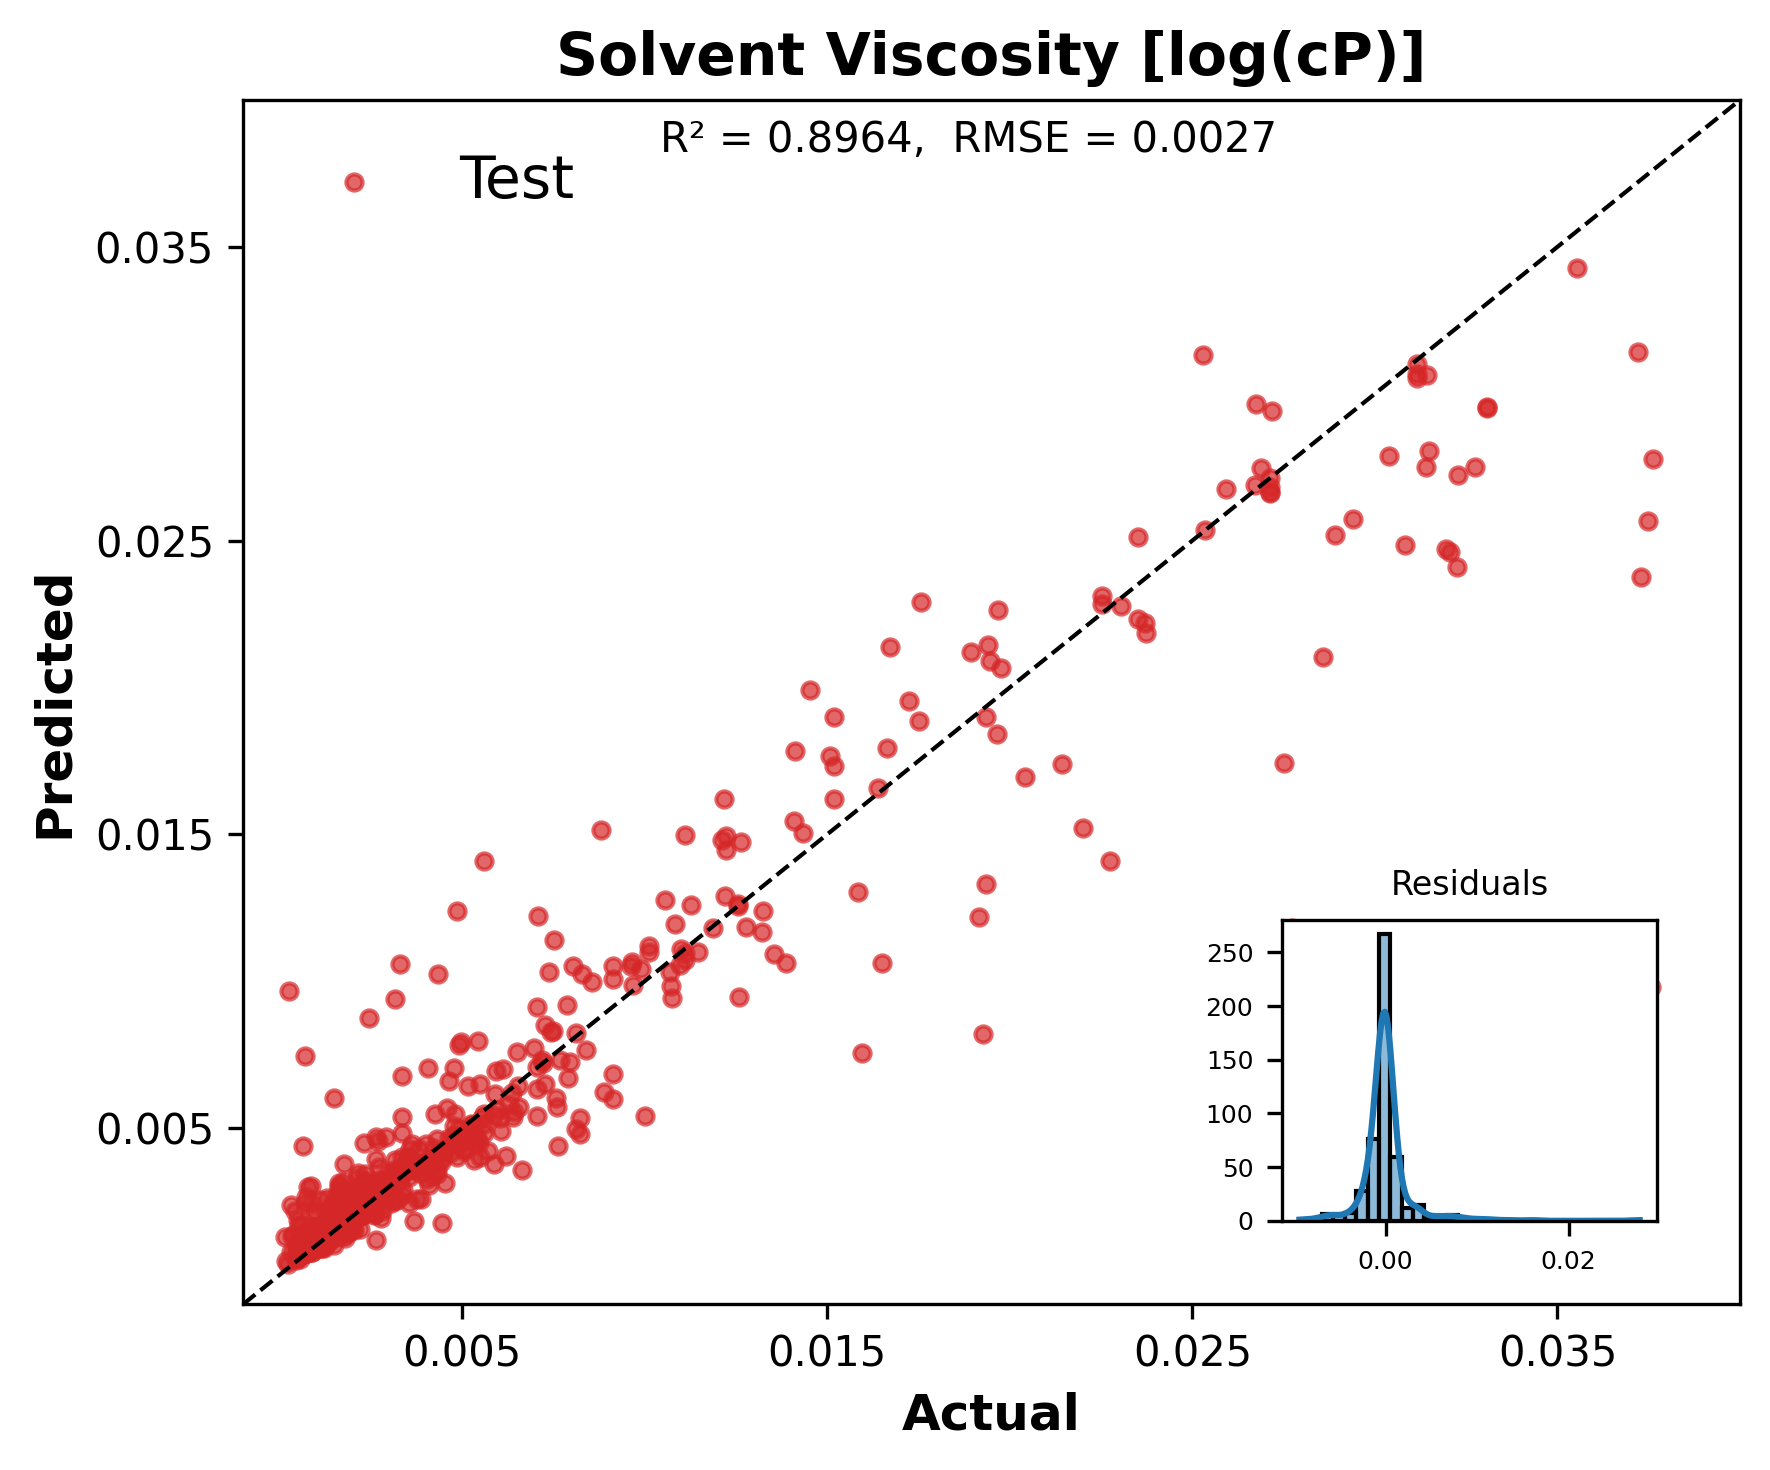

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

# ➤ Scatter plot and diagonal line

ax.scatter(y_test, y_pred, alpha=0.7, s=15, color='tab:red', marker='o', label='Test')
ax.plot([-0.001, 0.040], [-0.001, 0.040], 'k--', linewidth=1)

# ➤ Main plot labels
ax.set_title("Solvent Viscosity [log(cP)]", fontsize=14, fontweight='bold')
ax.set_xlabel("Actual", fontsize=12, fontweight='bold')
ax.set_ylabel("Predicted", fontsize=12, fontweight='bold')
ax.set_xlim(-0.001, 0.040)
ax.set_ylim(-0.001, 0.040)
ax.set_xticks([0.005, 0.015,0.025,0.035])
ax.set_yticks([0.005, 0.015,0.025,0.035])
ax.tick_params(axis='both', labelsize=10)

# ➤ R² and RMSE just inside top center of axes
x_center = (y_test.min() + y_test.max()) / 2
y_top = y_pred.max() + (y_pred.max() - y_pred.min()) * 0.15
ax.text(x_center, y_top, f"R² = {r2:.4f},  RMSE = {rmse:.4f}",
        fontsize=10, ha='center', va='top')

# ➤ Legend for Train/Test, slightly lowered at top-left, no frame
ax.legend(loc='upper left', fontsize=14, frameon=False)


# ➤ Inset plot for residuals
inset_ax = inset_axes(ax, width="25%", height="25%", loc='lower right', borderpad=2)


sns.histplot(residuals, bins=30, kde=True, ax=inset_ax)
inset_ax.set_title("Residuals", fontsize=8)
inset_ax.set_xlabel("")
inset_ax.set_ylabel("")
inset_ax.tick_params(labelsize=6)

# ➤ Adjust layout and save
plt.tight_layout()
plt.savefig("solvent_viscosity_fixed_TT.png", dpi=300, bbox_inches='tight')
plt.show()




C:\Users\nandi\AppData\Local\Temp\ipykernel_25660\2552240196.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


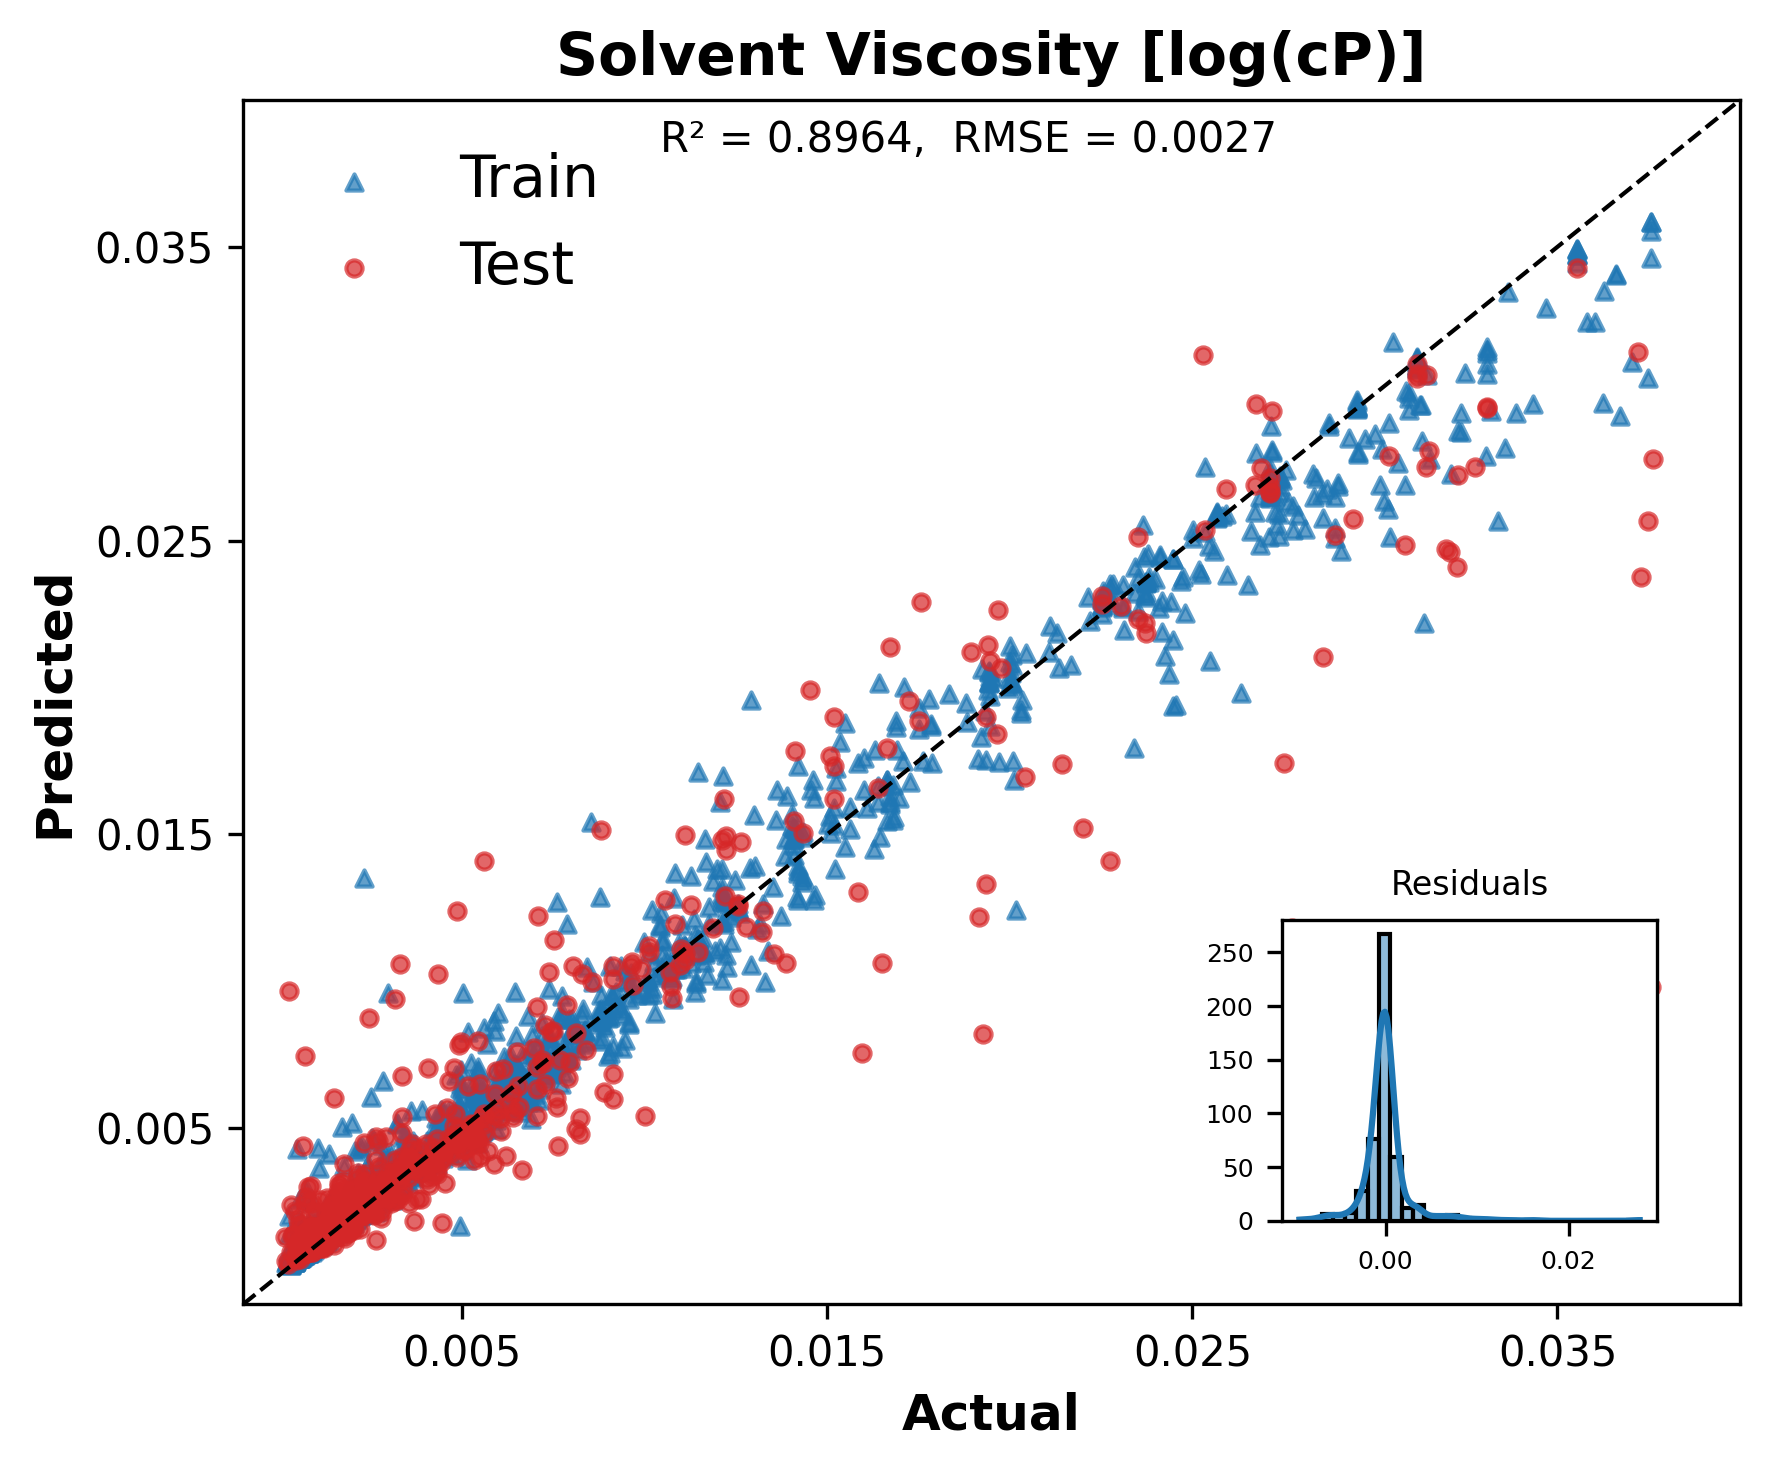

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes



# Invert the log transformation


fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

# ➤ Scatter plots
ax.scatter(y_train_act, y_train_pred, alpha=0.7, s=15, color='tab:blue', marker='^', label='Train')
ax.scatter(y_test, y_pred, alpha=0.7, s=15, color='tab:red', marker='o', label='Test')
ax.plot([-0.001, 0.040], [-0.001, 0.040], 'k--', linewidth=1)

# ➤ Main plot labels
ax.set_title("Solvent Viscosity [log(cP)]", fontsize=14, fontweight='bold')
ax.set_xlabel("Actual", fontsize=12, fontweight='bold')
ax.set_ylabel("Predicted", fontsize=12, fontweight='bold')
ax.set_xlim(-0.001, 0.040)
ax.set_ylim(-0.001, 0.040)
ax.set_xticks([0.005, 0.015, 0.025, 0.035])
ax.set_yticks([0.005, 0.015, 0.025, 0.035])
ax.tick_params(axis='both', labelsize=10)

# ➤ R² and RMSE text
x_center = (y_test.min() + y_test.max()) / 2
y_top = y_pred.max() + (y_pred.max() - y_pred.min()) * 0.15
ax.text(x_center, y_top, f"R² = {r2:.4f},  RMSE = {rmse:.4f}",
        fontsize=10, ha='center', va='top')

# ➤ Legend
ax.legend(loc='upper left', fontsize=14, frameon=False)

# ➤ Inset plot for residuals
inset_ax = inset_axes(ax, width="25%", height="25%", loc='lower right', borderpad=2)
sns.histplot(residuals, bins=30, kde=True, ax=inset_ax)
inset_ax.set_title("Residuals", fontsize=8)
inset_ax.set_xlabel("")
inset_ax.set_ylabel("")
inset_ax.tick_params(labelsize=6)

# ➤ Save and display
plt.tight_layout()
plt.savefig("solvent_viscosity_fixed_TT.png", dpi=300, bbox_inches='tight')
plt.show()


In [20]:
# import joblib

# # Save the XGBoost model
# joblib.dump(model, 'viscosity_xgboost_model.pkl')

# # Optionally, save the scaler as well for future predictions
# joblib.dump(scaler, 'scaler_viscocity_xgboost_model.pkl')

# print("Model and scaler saved successfully!")



In [21]:
import pandas as pd
import numpy as np

# 1. Get feature importance from SHAP
# Sum the absolute SHAP values for each feature to find the top ones
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': np.abs(shap_values.values).mean(axis=0)
}).sort_values(by='importance', ascending=False)

# 2. Select the top 6 features (adjust this number if you want a more precise equation)
top_features = feature_importance['feature'].head(10).tolist()

print(f"Top features for equation: {top_features}")

Top features for equation: ['fr_Al_OH_noTert', 'vib_freq_max_cm1', 'enthalpy of fusion [kJ/mol]', 'Xch-7dv', 'flash point [K]', 'SlogP_VSA1_x', 'SlogP_VSA1_y', 'NumHDonors', 'triple point temperature [K]', 'melting point [K]']


In [22]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Convert the scaled arrays back to DataFrames so we can use column names
# We use the original column names from 'X'
X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# 2. Now we can subset using the names you found
X_train_simple = X_train_df[top_features].dropna()
X_test_simple = X_test_df[top_features].dropna()

# 3. Get the corresponding y values (align indices)
y_train_log_clean = y_train_log.iloc[X_train_simple.index]
y_test_log_clean = y_test_log.iloc[X_test_simple.index]

# 4. Fit the Simple Linear Model
linear_model = LinearRegression()
linear_model.fit(X_train_simple, y_train_log_clean)

# 5. Check accuracy
y_pred_linear = linear_model.predict(X_test_simple)
rmse_lin = np.sqrt(mean_squared_error(y_test_log_clean, y_pred_linear))
r2_lin = r2_score(y_test_log_clean, y_pred_linear)

print("--- Simple Linear Equation ---")
print(f"RMSE: {rmse_lin:.4f}")
print(f"R² Score: {r2_lin:.4f}")
print("\nPredictive Equation:")
equation_terms = [f"({coef:.4f} * {name})" for name, coef in zip(top_features, linear_model.coef_)]
print(f"y = {linear_model.intercept_:.4f} + " + " + ".join(equation_terms))

--- Simple Linear Equation ---
RMSE: 0.0047
R² Score: 0.6815

Predictive Equation:
y = 0.0068 + (0.0045 * fr_Al_OH_noTert) + (-0.0044 * vib_freq_max_cm1) + (0.0009 * enthalpy of fusion [kJ/mol]) + (0.0008 * Xch-7dv) + (0.0008 * flash point [K]) + (-0.0012 * SlogP_VSA1_x) + (-0.0012 * SlogP_VSA1_y) + (0.0075 * NumHDonors) + (-0.0009 * triple point temperature [K]) + (0.0021 * melting point [K])


In [23]:
# Inverse log1p transformation for final predictions
y_pred_linear_final = np.expm1(y_pred_linear)
y_test_final = np.expm1(y_test_log_clean)


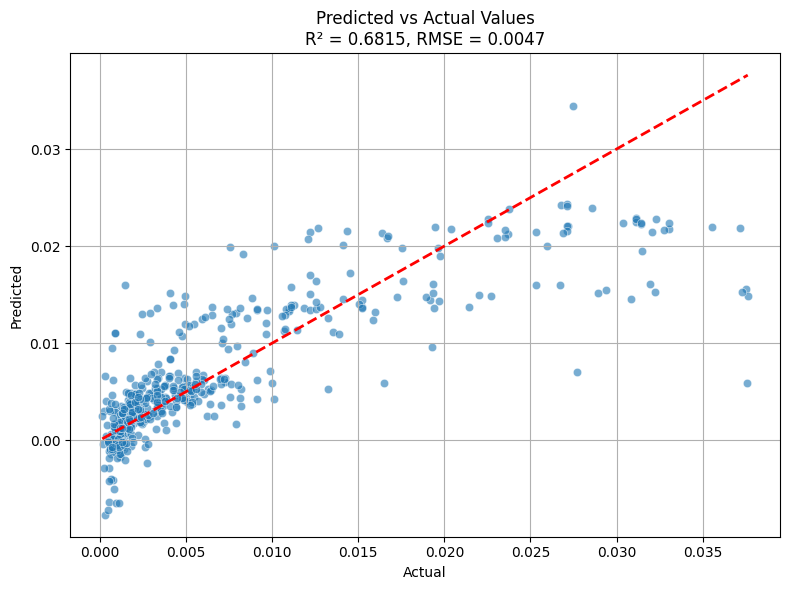

In [24]:
residuals_lin = y_test_final - y_pred_linear_final

import matplotlib.pyplot as plt
import seaborn as sns 

# --- A. Predicted vs Actual Plot ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_final, y=y_pred_linear_final, alpha=0.6)
plt.plot([y_test_final.min(), y_test_final.max()], [y_test_final.min(), y_test_final.max()],
         'r--', linewidth=2)

plt.title(f"Predicted vs Actual Values\nR² = {r2_lin:.4f}, RMSE = {rmse_lin:.4f}")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\nandi\AppData\Local\Temp\ipykernel_25660\48318990.py:10: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', linewidth=1, color='black')
C:\Users\nandi\AppData\Local\Temp\ipykernel_25660\48318990.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


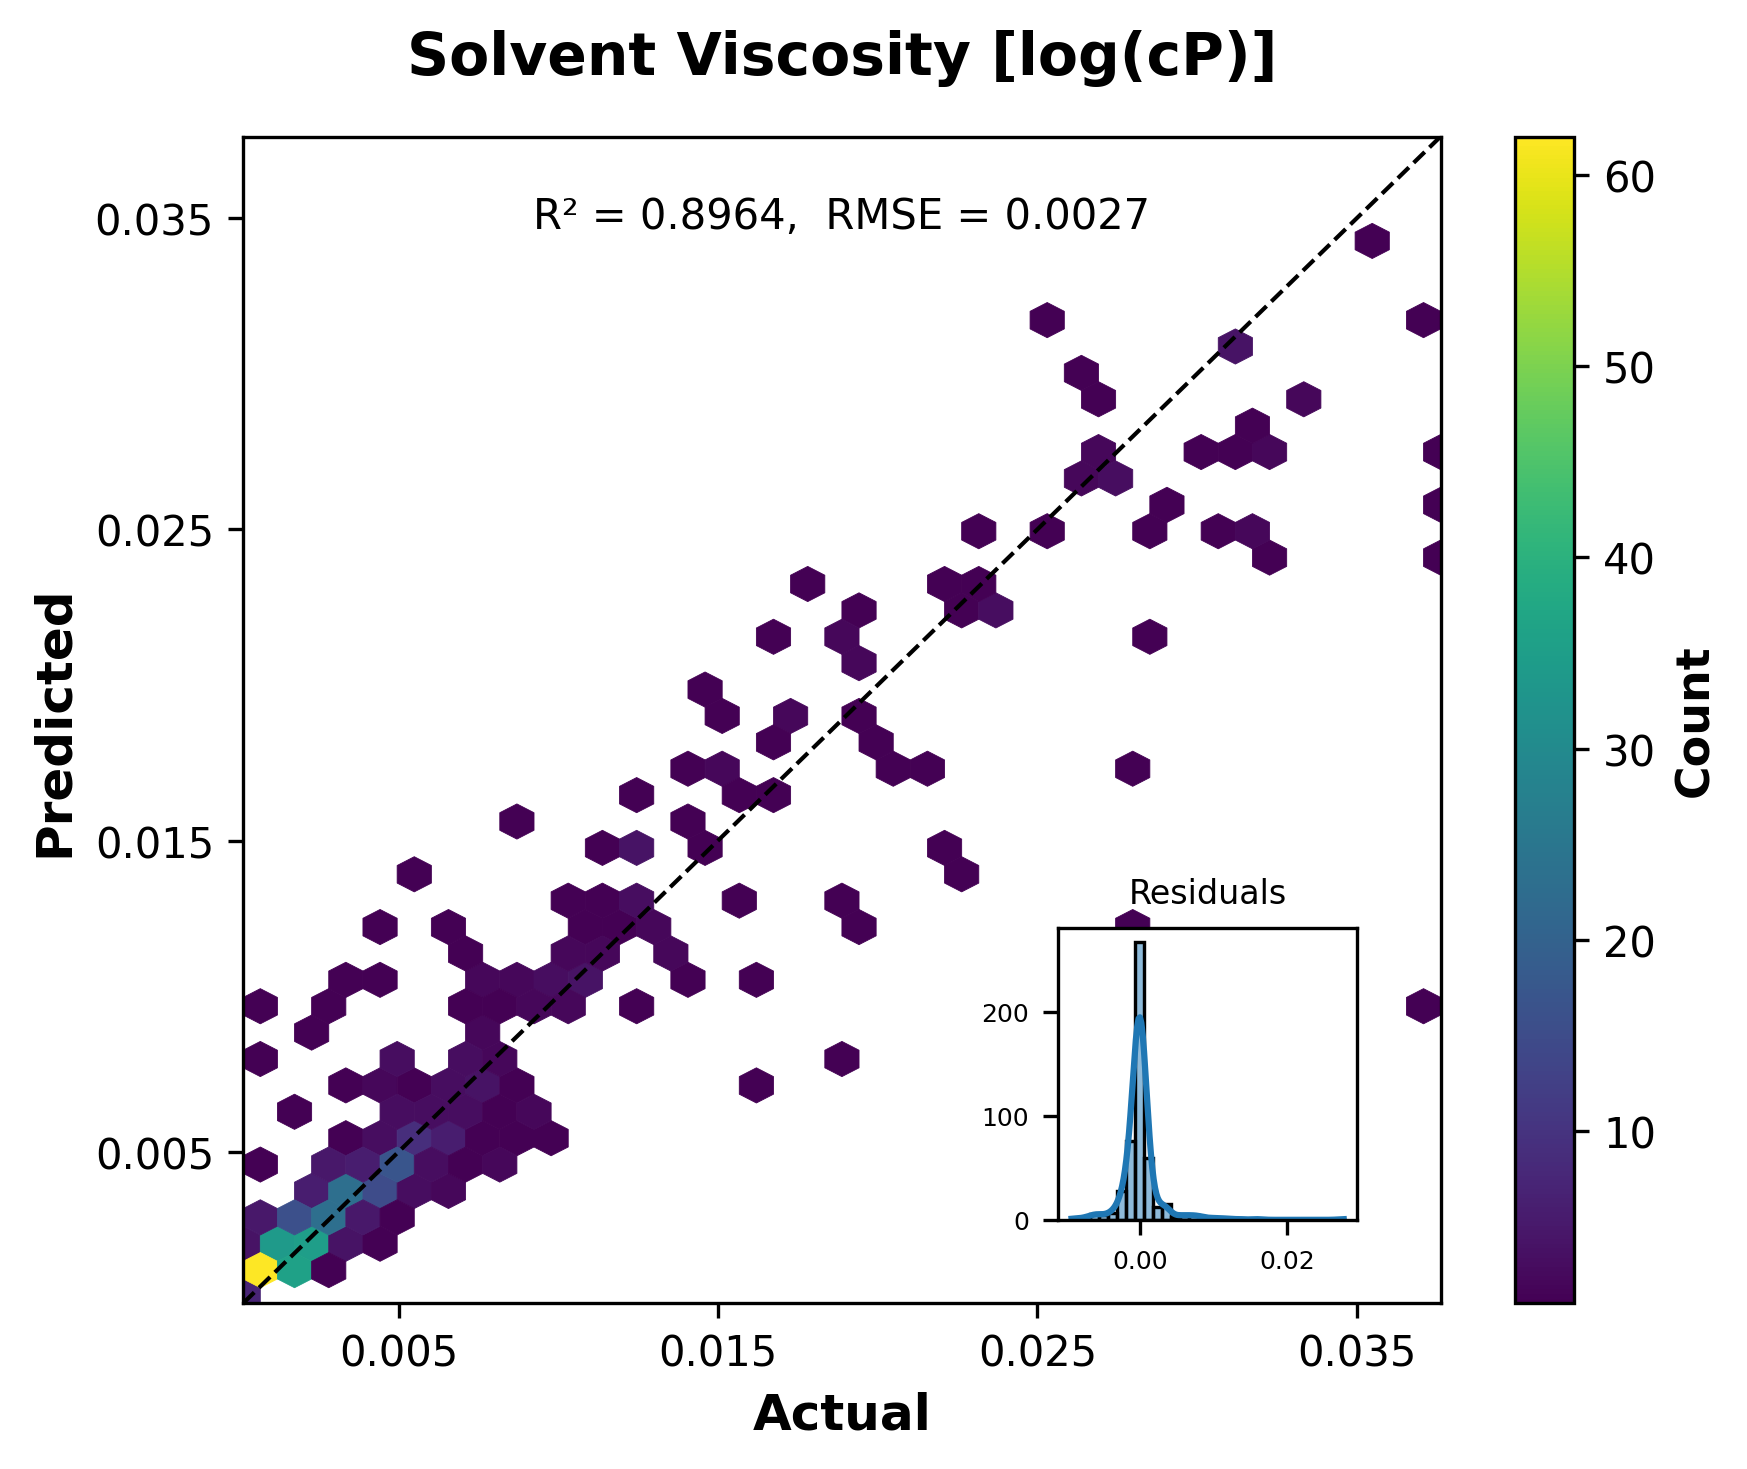

In [27]:
# Use point density plot (e.g. hexbin in matplotlib) instead of scatter plot for above to show the distribution information for the overlapped data points along with labeling the axes and adding a diagonal reference line.
fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

# Create hexbin plot with better visibility
hb = ax.hexbin(y_test, y_pred, gridsize=35, cmap='viridis', mincnt=1, edgecolors='face', linewidths=0.2)
cb = plt.colorbar(hb, ax=ax)
cb.set_label('Count', fontsize=11, fontweight='bold')

# Diagonal reference line
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', linewidth=1, color='black')

# remove 0 tick mark from x and y axis
ax.set_xticks([0.005, 0.015, 0.025, 0.035])
ax.set_yticks([0.005, 0.015, 0.025, 0.035])

# ax.set_xlim(-0.001, 0.040)
# ax.set_ylim(-0.001, 0.040)

# adjust x and y axis range (max 5 - as original scatter plot)
# diagonal line -make sure it spans the whole plot range.
ax.set_xlim(left=y_test.min(), right=y_test.max())
ax.set_ylim(bottom=y_test.min(), top=y_test.max())



# Title and axes labels
ax.set_title(f"Solvent Viscosity [log(cP)]", 
             fontsize=14, fontweight='bold', pad=15)
# this should be inside the plot
y_top = ax.get_ylim()[1] - 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0])
ax.text(x_center, y_top, f"R² = {r2:.4f},  RMSE = {rmse:.4f}",
        fontsize=10, ha='center', va='top')
ax.set_xlabel("Actual", fontsize=12, fontweight='bold')
ax.set_ylabel("Predicted", fontsize=12, fontweight='bold')
ax.tick_params(axis='both', labelsize=10)
# ➤ Inset residual plot
inset_ax = inset_axes(ax, width="25%", height="25%", loc='lower right', borderpad=2)
sns.histplot(residuals, bins=30, kde=True, ax=inset_ax)
inset_ax.set_title("Residuals", fontsize=8)
inset_ax.set_xlabel("")
inset_ax.set_ylabel("")
inset_ax.tick_params(labelsize=6)
# ax.legend(fontsize=11, loc='upper left')
# ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("Viscosity_hexbin_density_plot_.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\nandi\AppData\Local\Temp\ipykernel_25660\1589107705.py:10: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([y_test_final.min(), y_test_final.max()], [y_test_final.min(), y_test_final.max()], 'k--', linewidth=1, color='black')
C:\Users\nandi\AppData\Local\Temp\ipykernel_25660\1589107705.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


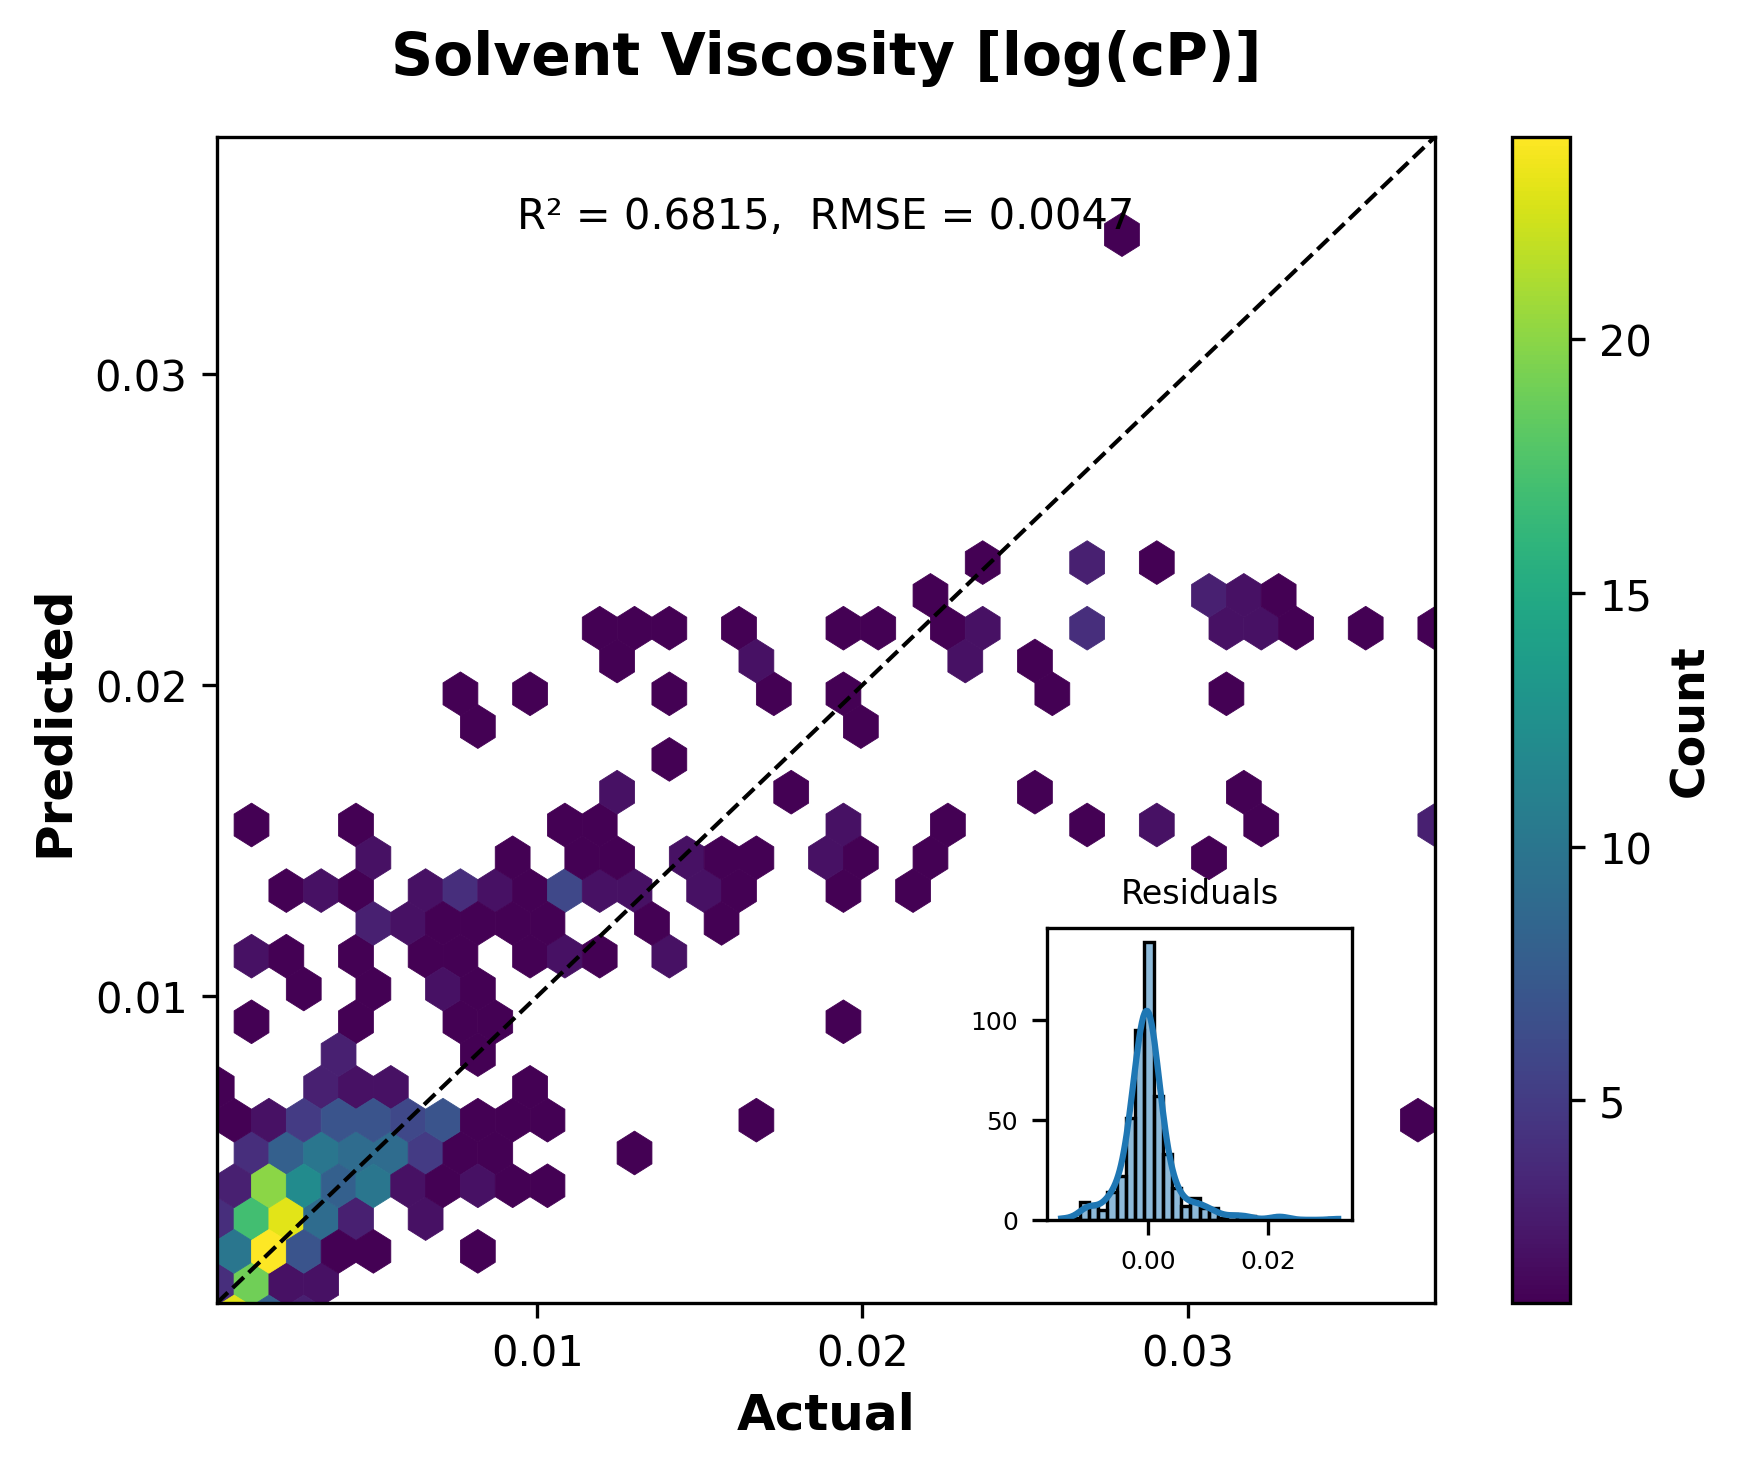

In [26]:
# Use point density plot (e.g. hexbin in matplotlib) instead of scatter plot for above to show the distribution information for the overlapped data points along with labeling the axes and adding a diagonal reference line.
fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

# Create hexbin plot with better visibility
hb = ax.hexbin(y_test_final, y_pred_linear_final, gridsize=35, cmap='viridis', mincnt=1, edgecolors='face', linewidths=0.2)
cb = plt.colorbar(hb, ax=ax)
cb.set_label('Count', fontsize=11, fontweight='bold')

# Diagonal reference line
ax.plot([y_test_final.min(), y_test_final.max()], [y_test_final.min(), y_test_final.max()], 'k--', linewidth=1, color='black')

# remove 0 tick mark from x and y axis
ax.set_xticks([tick for tick in ax.get_xticks() if tick != 0])
ax.set_yticks([tick for tick in ax.get_yticks() if tick != 0])

# adjust x and y axis range (max 5 - as original scatter plot)
# diagonal line -make sure it spans the whole plot range.
ax.set_xlim(left=y_test_final.min(), right=y_test_final.max())
ax.set_ylim(bottom=y_test_final.min(), top=y_test_final.max())


# Title and axes labels
ax.set_title(f"Solvent Viscosity [log(cP)]", 
             fontsize=14, fontweight='bold', pad=15)
ax.text(x_center, y_top, f"R² = {r2_lin:.4f},  RMSE = {rmse_lin:.4f}",
        fontsize=10, ha='center', va='top')
ax.set_xlabel("Actual", fontsize=12, fontweight='bold')
ax.set_ylabel("Predicted", fontsize=12, fontweight='bold')
ax.tick_params(axis='both', labelsize=10)
# ➤ Inset residual plot
inset_ax = inset_axes(ax, width="25%", height="25%", loc='lower right', borderpad=2)
sns.histplot(residuals_lin, bins=30, kde=True, ax=inset_ax)
inset_ax.set_title("Residuals", fontsize=8)
inset_ax.set_xlabel("")
inset_ax.set_ylabel("")
inset_ax.tick_params(labelsize=6)
# ax.legend(fontsize=11, loc='upper left')
# ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("IP_hexbin_density_plot_lr.png", dpi=300, bbox_inches='tight')
plt.show()